In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
# 1. Đọc và xử lý dữ liệu
# Đọc file CSV
true_df = pd.read_csv('News _dataset/True.csv')
fake_df = pd.read_csv('News _dataset/Fake.csv')

# Thêm nhãn
true_df['label'] = 1
fake_df['label'] = 0

In [3]:
# Gộp dữ liệu
data = pd.concat([true_df, fake_df], ignore_index=True) 
# Hàm làm sạch văn bản
def clean_text(text):
    text = re.sub(r'\s+', ' ', text)  # Xóa khoảng trắng thừa
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Giữ lại chữ cái
    return text.strip().lower() 
# Làm sạch văn bản
data['text'] = data['text'].apply(clean_text) 

In [4]:
# 2. Load file embeddings
embeddings_file = "embeddings.pkl"  # Thay bằng đường dẫn của bạn
embeddings_data = pd.read_pickle(embeddings_file)

# Tách embeddings và labels
embeddings = np.stack(embeddings_data['embedding'].values)
labels = embeddings_data['label'].values 

In [5]:
# 3. Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42) 

In [6]:
# 4. Xây dựng mô hình RNN đơn giản
model = Sequential([
    Dense(256, activation='relu', input_shape=(768,)),  # Lớp đầu vào
    Dropout(0.5),  # Dropout để giảm overfitting
    Dense(64, activation='relu'),  # Lớp ẩn
    Dense(1, activation='sigmoid')  # Lớp đầu ra (phân loại nhị phân)
]) 

c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 

In [8]:
# 5. Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2) 

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9056 - loss: 0.2260 - val_accuracy: 0.9626 - val_loss: 0.1062
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9572 - loss: 0.1193 - val_accuracy: 0.9695 - val_loss: 0.0874
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9624 - loss: 0.1053 - val_accuracy: 0.9724 - val_loss: 0.0792
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9690 - loss: 0.0889 - val_accuracy: 0.9653 - val_loss: 0.0865
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9728 - loss: 0.0788 - val_accuracy: 0.9756 - val_loss: 0.0730
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9711 - loss: 0.0806 - val_accuracy: 0.9754 - val_loss: 0.0730
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9718 - loss: 0.0784 - val_accuracy: 0.9769 - val_loss: 0.0654
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9746 - loss: 0.0706 - val_accuracy: 

In [9]:
# Đánh giá mô hình
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}") 

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9810 - loss: 0.0518
Test Loss: 0.050749827176332474, Test Accuracy: 0.9820712804794312


In [10]:
# 6. Dự đoán với văn bản mới
# Load tokenizer và model BERT
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased') 

c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Hàm nhúng văn bản
def embed_text(text):
    tokens = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors='pt')
    with torch.no_grad():
        outputs = bert_model(**tokens)
    return outputs.last_hidden_state.mean(dim=1).numpy() 
# Hàm dự đoán tin tức
def check_fake_news(text):
    # Làm sạch và nhúng văn bản
    clean_text_input = clean_text(text)
    embedding = embed_text([clean_text_input])[0]
    # Dự đoán
    prediction = model.predict(np.array([embedding]))
    return "Real" if prediction[0] > 0.5 else "Fake" 

In [12]:
# Thử nghiệm với một văn bản mới
new_text = "Washington CNN — President-elect Donald Trump repeated numerous false claims during an interview that aired Sunday on NBC’s “Meet the Press” – including his old lie that the US is the world’s only country with birthright citizenship."
print(f"Dự đoán: {check_fake_news(new_text)}") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Dự đoán: Real


In [13]:
model.save('RNN_model_using_BERT.h5')

In [14]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# Dự đoán nhãn của tập kiểm tra
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()  # Chuyển kết quả dự đoán thành nhãn 0 hoặc 1

# Tính toán các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4650
           1       0.98      0.98      0.98      4330

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980

Accuracy: 0.98
Precision: 0.98
Recall: 0.98
F1 Score: 0.98


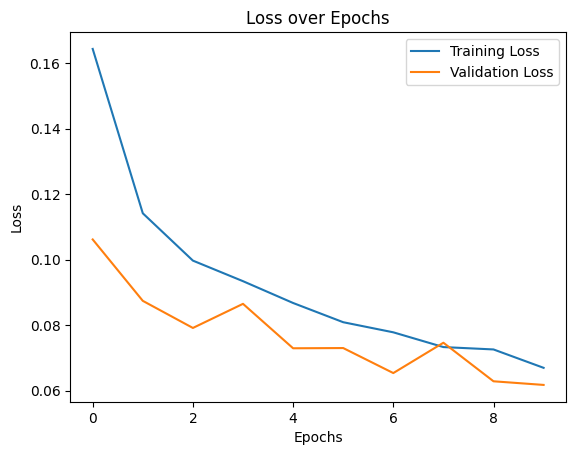

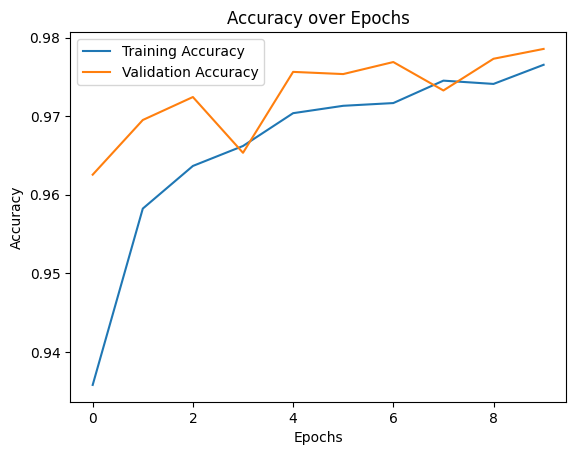

In [15]:
import matplotlib.pyplot as plt
# Vẽ biểu đồ Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Vẽ biểu đồ Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()